# Spot Tolerance Cost Analysis — Scenario A (Mooncake long-context)

In [ ]:
import json
import os
import re
import glob
from collections import defaultdict
from itertools import groupby

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

# ── Configuration ──────────────────────────────────────────────────────────────
SCENARIO = "A"

MODEL_CONFIGS = {
    "llama3-70b": {
        "benchmark_duration_min": 50,
        "az_selection": {
            "g5.12xlarge": "us-west-2c",
            "g6.12xlarge": "us-west-2c",
            "g6e.xlarge": "us-west-2a",
        },
    },
}

APPROACHES = ["only_ondemand", "shuntserve", "concurrent_initialization",
              "request_migration", "no_handle"]
OVERLAP_APPROACHES = {"shuntserve", "concurrent_initialization"}

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Display config ────────────────────────────────────────────────────────────
DISPLAY_NAMES = {
    "only_ondemand": "On-demand\nOnly",
    "no_handle": "No Handle",
    "request_migration": "Request\nMigration",
    "concurrent_initialization": "Concurrent\nInitialization",
    "shuntserve": "ShuntServe",
}
PLOT_ORDER = ["only_ondemand", "no_handle", "request_migration",
              "concurrent_initialization", "shuntserve"]
COLORS = {
    "only_ondemand": "#808080",
    "no_handle": "#d62728",
    "request_migration": "#2ca02c",
    "concurrent_initialization": "#ff7f0e",
    "shuntserve": "#1f77b4",
}
HATCHES = {
    "only_ondemand": "",
    "no_handle": "/",
    "request_migration": "\\",
    "concurrent_initialization": "x",
    "shuntserve": ".",
}

# ── Per-figure styling (tweak freely) ───────────────────────────────────────────
# Throughput and Cost-Efficiency share the SAME figsize so the two figures match.
# Adjust font size / figure size per figure here.
# figsize unified to the paper .py bar (6x4) so hatch spacing & edge weight match
# spottolerance_llama3_70b_analyze_results.py; fonts bumped for legibility at that size.
THROUGHPUT_FIGSIZE = (6, 4)
THROUGHPUT_FONTSIZE = 22
COST_EFFICIENCY_FIGSIZE = (6, 4)
COST_EFFICIENCY_FONTSIZE = 22
NORM_TPUT_FIGSIZE = (6, 4)        # Azure-vs-Mooncake normalized-throughput comparison
NORM_TPUT_FONTSIZE = 22
TICK_FONTSIZE = 16               # axis tick labels — kept smaller than the axis label
BAR_LABEL_FONTSIZE = 16          # bar-top value labels (throughput & cost-efficiency), horizontal
Y_TICK_NBINS = 6                 # target number of y ticks (finer than the mpl default)
THROUGHPUT_SHOW_LABELS = True    # set True to draw the value labels on the throughput bars

# Shared axes box so (a) Throughput & (b) Cost-Efficiency line up when placed
# side by side in LaTeX. Both are saved at the EXACT figsize (no bbox_inches="tight"
# crop) with these identical margins, so their plot boxes occupy the same rectangle.
FIG_MARGINS = dict(left=0.20, right=0.96, top=0.95, bottom=0.09)

print(f"Scenario: {SCENARIO}")
for mk, cfg in MODEL_CONFIGS.items():
    print(f"  {mk}: duration={cfg['benchmark_duration_min']}min")

In [2]:
# ── Helper Functions ───────────────────────────────────────────────────────────

def node_to_group(name: str) -> str:
    """spot_g6e_xlarge_node_ip_1 → spot_g6e_xlarge"""
    return re.sub(r"_node_ip_\d+$", "", name)

def group_to_instance_type(group: str) -> str:
    """spot_g6e_xlarge → g6e.xlarge"""
    bare = re.sub(r"^(spot|on_demand)_", "", group)
    return re.sub(r"_(\d*xlarge)$", r".\1", bare)

def is_spot_group(group: str) -> bool:
    return group.startswith("spot_")


# ── load_data ─────────────────────────────────────────────────────────────────

def load_data(model_key: str, scenario: str) -> dict:
    """Load all data files and compute initial state."""
    mk_underscore = model_key.replace("-", "_")

    with open(f"results/prices_scenario_{scenario}.json") as f:
        prices_data = json.load(f)
    with open(f"spot_trace_events_scenario_{scenario}.json") as f:
        events_raw = json.load(f)["events"]
    with open(f"nodes_scenario_{scenario}.json") as f:
        nodes_data = json.load(f)
    with open(f"{model_key}/pipelines_{mk_underscore}_scenario_{scenario}.json") as f:
        pipeline_data = json.load(f)

    # Parse node groups
    all_node_groups = defaultdict(int)
    for name in nodes_data:
        all_node_groups[node_to_group(name)] += 1

    # Parse initial active nodes from pipeline
    initial_active = defaultdict(int)
    for pipeline in pipeline_data["pipelines"]:
        for node_name, _layers in pipeline["node_layer_mapping"]:
            initial_active[node_to_group(node_name)] += 1

    # Per instance type: initial (spot_active, od_active)
    instance_types = set(group_to_instance_type(g) for g in all_node_groups)
    initial_state = {}
    for itype in sorted(instance_types):
        spot_total = od_total = spot_active = od_active = 0
        for g, cnt in all_node_groups.items():
            if group_to_instance_type(g) == itype:
                if is_spot_group(g):
                    spot_total += cnt
                    spot_active += initial_active.get(g, 0)
                else:
                    od_total += cnt
                    od_active += initial_active.get(g, 0)
        initial_state[itype] = {
            "spot_active": spot_active, "od_active": od_active,
            "spot_total": spot_total, "od_total": od_total,
        }

    print(f"[{model_key}] Node groups: {dict(sorted(all_node_groups.items()))}")
    print(f"[{model_key}] Initial state: {initial_state}")

    return {
        "prices_data": prices_data,
        "events_raw": events_raw,
        "nodes_data": nodes_data,
        "pipeline_data": pipeline_data,
        "all_node_groups": dict(all_node_groups),
        "instance_types": instance_types,
        "initial_state": initial_state,
        "initial_active": dict(initial_active),
    }

In [3]:
# ── parse_metrics ──────────────────────────────────────────────────────────────

def _parse_switching_times(log_path: str) -> list[float]:
    times = []
    with open(log_path) as f:
        for line in f:
            m = re.search(r"(?:switch completed|recreated) in (\d+\.?\d*)s", line)
            if m:
                times.append(float(m.group(1)))
    return times

def _find_trace_csv(approach: str, trace_dir: str, prefix: str,
                    mk_underscore: str, scenario: str) -> str | None:
    patterns = [
        f"{trace_dir}/spottolerance_{prefix}_{approach}_{mk_underscore}_scenario_{scenario}_*.csv",
        f"{trace_dir}/spottolerance_{prefix}_{approach}_scenario_{scenario}_*.csv",
    ]
    for pat in patterns:
        matches = sorted(glob.glob(pat))
        if matches:
            return matches[-1]
    return None

def _calc_throughput(csv_path: str, duration_min: int) -> float:
    """Average RPS — the paper fig13-14 throughput metric (matches
    spottolerance_llama3_70b_analyze_results.ipynb::calculate_rps_with_moving_average):
    mean of a trailing 5-min-window completion rate, sampled every second over
    [0, duration_min*60]. This is NOT a plain completed/duration count — it is used so
    throughput / efficiency / improvement numbers line up with the published figures.
    """
    df = pd.read_csv(csv_path)
    ct = df["CompletionTime"].values - df["ArrivalTime"].min()
    window = 300                       # 5-min trailing window (paper)
    max_time = duration_min * 60       # e.g. 50 min -> 3000 s
    rps = np.array([
        np.sum((ct >= max(0, t - window)) & (ct < t)) / window
        for t in range(0, max_time + 1)
    ])
    return float(rps.mean())

def _calc_mean_latency(csv_path: str, duration_min: int) -> float:
    df = pd.read_csv(csv_path)
    t0 = df["ArrivalTime"].min()
    cutoff = t0 + duration_min * 60
    sub = df[df["CompletionTime"] <= cutoff]
    return (sub["CompletionTime"] - sub["ArrivalTime"]).mean()


def parse_metrics(model_key: str, scenario: str, benchmark_duration_min: int,
                  approaches: list[str]) -> dict:
    """Parse switching times, offline throughputs, online metrics."""
    mk_underscore = model_key.replace("-", "_")
    log_dir = f"{model_key}/offline/scenario_{scenario}/logs"
    trace_dir = f"results/{model_key}/offline/scenario_{scenario}/Trace"
    online_trace_dir = f"results/{model_key}/online/scenario_{scenario}/Trace"

    switching_times = {}
    throughputs = {}
    online_throughputs = {}
    online_mean_latencies = {}

    for approach in approaches:
        # Switching times from logs
        log_path = os.path.join(log_dir, f"{approach}.log")
        if os.path.exists(log_path):
            st = _parse_switching_times(log_path)
            if st:
                switching_times[approach] = st

        # Offline throughput from CSV
        csv_path = _find_trace_csv(approach, trace_dir, "offline", mk_underscore, scenario)
        if csv_path:
            throughputs[approach] = _calc_throughput(csv_path, benchmark_duration_min)

        # Online metrics from CSV
        csv_path = _find_trace_csv(approach, online_trace_dir, "online", mk_underscore, scenario)
        if csv_path:
            online_throughputs[approach] = _calc_throughput(csv_path, benchmark_duration_min)
            online_mean_latencies[approach] = _calc_mean_latency(csv_path, benchmark_duration_min)

    print(f"[{model_key}] Switching times: {switching_times}")
    print(f"[{model_key}] Offline throughputs: { {a: f'{v:.4f}' for a,v in throughputs.items()} }")
    if online_mean_latencies:
        print(f"[{model_key}] Online mean latencies: { {a: f'{v:.2f}' for a,v in online_mean_latencies.items()} }")

    return {
        "switching_times": switching_times,
        "throughputs": throughputs,
        "online_throughputs": online_throughputs,
        "online_mean_latencies": online_mean_latencies,
    }

In [4]:
# ── compute_active_periods ────────────────────────────────────────────────────

def compute_active_periods(events_raw: list, initial_state: dict,
                           instance_types: set, benchmark_duration_min: int) -> dict:
    """Compute timeline segments and compound outgoing nodes."""

    events = [e for e in events_raw if e["time_min"] < benchmark_duration_min]
    events_sorted = sorted(events, key=lambda e: e["time_min"])
    compound_events = []
    for t, grp in groupby(events_sorted, key=lambda e: e["time_min"]):
        compound_events.append({"time_min": t, "sub_events": list(grp)})

    def _count_spot_nodes(sub_event):
        counts = defaultdict(int)
        for inst in sub_event["instances"]:
            group = node_to_group(inst)
            if is_spot_group(group):
                counts[group_to_instance_type(group)] += 1
        return dict(counts)

    # Build timeline segments
    state = {i: {"spot": s["spot_active"], "od": s["od_active"]}
             for i, s in initial_state.items()}
    segments = {i: [] for i in instance_types}
    last_time = 0

    for ce in compound_events:
        t = ce["time_min"]
        if t > last_time:
            for i in instance_types:
                segments[i].append((last_time, t, state[i]["spot"], state[i]["od"]))
        for se in ce["sub_events"]:
            for itype, n in _count_spot_nodes(se).items():
                if se["type"] == "interruption":
                    state[itype]["spot"] -= n
                    state[itype]["od"] += n
                else:
                    state[itype]["spot"] += n
                    state[itype]["od"] -= n
        last_time = t

    for i in instance_types:
        segments[i].append((last_time, benchmark_duration_min, state[i]["spot"], state[i]["od"]))

    # Compute outgoing nodes per compound event (for overlap cost)
    overlap_state = {i: {"spot": s["spot_active"], "od": s["od_active"]}
                     for i, s in initial_state.items()}
    compound_outgoing = []
    for ce in compound_events:
        outgoing = {}
        for se in ce["sub_events"]:
            for itype, n in _count_spot_nodes(se).items():
                if se["type"] == "interruption":
                    outgoing[itype] = {"count": n, "is_spot": True}
                    overlap_state[itype]["spot"] -= n
                    overlap_state[itype]["od"] += n
                else:
                    outgoing[itype] = {"count": n, "is_spot": False}
                    overlap_state[itype]["spot"] += n
                    overlap_state[itype]["od"] -= n
        compound_outgoing.append(outgoing)

    print(f"  Compound events: {len(compound_events)}")
    return {
        "segments": segments,
        "compound_events": compound_events,
        "compound_outgoing": compound_outgoing,
    }

In [5]:
# ── Price Lookup ───────────────────────────────────────────────────────────────

def _get_spot_prices_by_az(prices_data: dict, instance_type: str) -> dict[str, float]:
    az_prices = defaultdict(list)
    for entry in prices_data["spot"]:
        if entry["Instance"] == instance_type:
            az_prices[entry["AZ"]].append(float(entry["Price"]))
    return {az: sum(ps) / len(ps) for az, ps in az_prices.items()}

def _get_ondemand_price(prices_data: dict, instance_type: str) -> float:
    for entry in prices_data["ondemand"]:
        if entry["Instance"] == instance_type:
            return float(entry["PricePerHour_USD"])
    raise ValueError(f"On-demand price not found for {instance_type}")

def _get_spot_price(prices_data: dict, instance_type: str,
                    az_selection: dict, mode: str = "avg") -> float:
    az_prices = _get_spot_prices_by_az(prices_data, instance_type)
    if not az_prices:
        raise ValueError(f"No spot price data for {instance_type}")
    if instance_type in az_selection and az_selection[instance_type]:
        az = az_selection[instance_type]
        if az in az_prices:
            return az_prices[az]
        raise ValueError(f"AZ {az} not found for {instance_type}")
    all_prices = list(az_prices.values())
    if mode == "avg":
        return sum(all_prices) / len(all_prices)
    elif mode == "min":
        return min(all_prices)
    elif mode == "max":
        return max(all_prices)
    raise ValueError(f"Unknown mode: {mode}")

In [6]:
# ── Cost Calculation ───────────────────────────────────────────────────────────

def calculate_all_costs(data: dict, periods: dict, metrics: dict,
                        az_selection: dict, benchmark_duration_min: int,
                        approaches: list[str], mode: str = "avg") -> dict[str, float]:
    """Calculate cost for each approach under a given spot price mode."""
    prices_data = data["prices_data"]
    initial_state = data["initial_state"]
    instance_types = data["instance_types"]
    segments = periods["segments"]
    compound_outgoing = periods["compound_outgoing"]
    switching_times = metrics["switching_times"]

    # 1. ondemand_only: all initial pipeline nodes at on-demand price
    pipeline_node_counts = defaultdict(int)
    for itype in instance_types:
        s = initial_state[itype]
        pipeline_node_counts[itype] = s["spot_active"] + s["od_active"]

    ondemand_cost = 0.0
    for itype, count in pipeline_node_counts.items():
        if count > 0:
            ondemand_cost += count * _get_ondemand_price(prices_data, itype) * benchmark_duration_min / 60

    # 2. Base mixed cost
    base_cost = 0.0
    for itype in instance_types:
        spot_price = _get_spot_price(prices_data, itype, az_selection, mode) if initial_state[itype]["spot_total"] > 0 else 0
        od_price = _get_ondemand_price(prices_data, itype) if initial_state[itype]["od_total"] > 0 else 0
        for t_start, t_end, spot_n, od_n in segments[itype]:
            duration_hr = (t_end - t_start) / 60
            base_cost += spot_n * spot_price * duration_hr
            base_cost += od_n * od_price * duration_hr

    # 3. Overlap cost per approach
    results = {"only_ondemand": ondemand_cost}
    for approach in approaches:
        if approach == "only_ondemand":
            continue
        total_cost = base_cost
        if approach in OVERLAP_APPROACHES and approach in switching_times:
            for i, outgoing in enumerate(compound_outgoing):
                if i < len(switching_times[approach]):
                    switch_sec = switching_times[approach][i]
                    for itype, info in outgoing.items():
                        if info["is_spot"]:
                            price = _get_spot_price(prices_data, itype, az_selection, mode)
                        else:
                            price = _get_ondemand_price(prices_data, itype)
                        total_cost += info["count"] * price * switch_sec / 3600
        results[approach] = total_cost

    return results


def compute_costs(data: dict, periods: dict, metrics: dict,
                  az_selection: dict, benchmark_duration_min: int,
                  approaches: list[str]) -> tuple[dict, list[str]]:
    """Compute costs for all applicable spot price modes."""
    instance_types = data["instance_types"]
    initial_state = data["initial_state"]

    all_az_specified = all(
        itype in az_selection and az_selection[itype]
        for itype in instance_types
        if initial_state[itype]["spot_total"] > 0
    )
    modes = ["avg"] if all_az_specified else ["avg", "min", "max"]

    cost_results = {}
    for mode in modes:
        cost_results[mode] = calculate_all_costs(
            data, periods, metrics, az_selection, benchmark_duration_min, approaches, mode
        )

    return cost_results, modes

In [ ]:
# ── Plot & Summary Functions ───────────────────────────────────────────────────

def print_summary(cost_results, modes, metrics, model_key, benchmark_duration_min):
    """Print summary table."""
    throughputs = metrics["throughputs"]
    online_mean_latencies = metrics["online_mean_latencies"]

    rows = []
    for mode in modes:
        for approach in APPROACHES:
            cost = cost_results[mode].get(approach)
            tput = throughputs.get(approach)
            lat = online_mean_latencies.get(approach)
            rows.append({
                "Approach": approach,
                "Spot Price Mode": mode,
                "Cost ($)": f"{cost:.4f}" if cost is not None else "N/A",
                "Offline Throughput (req/s)": f"{tput:.2f}" if tput is not None else "N/A",
                "Online Mean Latency (s)": f"{lat:.2f}" if lat is not None else "N/A",
            })
    display(pd.DataFrame(rows))


def plot_cost_comparison(cost_results, modes, model_key):
    """Bar chart of total cost per approach."""
    mode = modes[0]
    costs_dict = cost_results[mode]
    values = [costs_dict[a] for a in PLOT_ORDER]

    fontsize = 22
    fig, ax = plt.subplots(figsize=(6, 4))
    for i, a in enumerate(PLOT_ORDER):
        ax.bar(i, costs_dict[a], width=0.8, color=COLORS[a], alpha=1.0,
               edgecolor="black", linewidth=1.5, hatch=HATCHES[a])
    for i, v in enumerate(values):
        ax.text(i, v + max(values) * 0.02, f"{v:.2f}",
                ha="center", va="bottom", fontsize=BAR_LABEL_FONTSIZE, rotation=90)

    ax.set_ylabel("Cost ($)", fontsize=fontsize)
    ax.set_xticks(range(len(PLOT_ORDER)))
    ax.set_xticklabels([])
    ax.set_xlabel(" ", fontsize=fontsize)
    ax.set_ylim(0, max(values) * 1.45)
    ax.tick_params(axis="y", labelsize=TICK_FONTSIZE)
    # ax.grid(True, axis="y", alpha=0.3, linestyle="--")
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))

    mk_suffix = model_key.replace("-", "_")
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/cost_comparison_scenario_{SCENARIO}_{mk_suffix}.pdf",
                dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {FIGURES_DIR}/cost_comparison_scenario_{SCENARIO}_{mk_suffix}.pdf")


def plot_cost_efficiency(cost_results, modes, metrics, model_key):
    """Offline / Online(Avg) / Online(P90) — normalized cost-per-performance.
    On-demand Only = 1.00 (100%). Lower bar = more cost-efficient.
    Labels show how much cheaper (e.g. -30.0%).
    """
    mode = modes[0]
    costs_dict = cost_results[mode]
    throughputs = metrics["throughputs"]
    online_mean_latencies = metrics["online_mean_latencies"]

    cfg = MODEL_CONFIGS[model_key]
    bdm = cfg["benchmark_duration_min"]
    mk_underscore = model_key.replace("-", "_")

    # Offline: Cost / Throughput, normalized to On-demand Only = 1.0
    offline_cpp = {}
    for a in PLOT_ORDER:
        if a in throughputs and a in costs_dict and costs_dict[a] > 0 and throughputs[a] > 0:
            offline_cpp[a] = costs_dict[a] / throughputs[a]
    offline_baseline = offline_cpp.get("only_ondemand", 1)
    offline_norm = {a: offline_cpp[a] / offline_baseline for a in PLOT_ORDER if a in offline_cpp}

    # Online Avg: Cost × MeanLatency, normalized to On-demand Only = 1.0
    online_avg_norm = {}
    if online_mean_latencies:
        online_avg_cpp = {}
        for a in PLOT_ORDER:
            if a in online_mean_latencies and a in costs_dict and costs_dict[a] > 0:
                online_avg_cpp[a] = costs_dict[a] * online_mean_latencies[a]
        online_avg_baseline = online_avg_cpp.get("only_ondemand", 1)
        online_avg_norm = {a: online_avg_cpp[a] / online_avg_baseline for a in PLOT_ORDER if a in online_avg_cpp}

    # Online P90: Cost × P90Latency, normalized to On-demand Only = 1.0
    online_p90_norm = {}
    online_trace_dir = f"results/{model_key}/online/scenario_{SCENARIO}/Trace"
    online_p90_lat = {}
    for a in PLOT_ORDER:
        csv_path = _find_trace_csv(a, online_trace_dir, "online", mk_underscore, SCENARIO)
        if csv_path:
            df = pd.read_csv(csv_path)
            t0 = df["ArrivalTime"].min()
            cutoff = t0 + bdm * 60
            sub = df[df["CompletionTime"] <= cutoff]
            online_p90_lat[a] = np.percentile((sub["CompletionTime"] - sub["ArrivalTime"]).values, 90)
    if online_p90_lat:
        online_p90_cpp = {}
        for a in PLOT_ORDER:
            if a in online_p90_lat and a in costs_dict and costs_dict[a] > 0:
                online_p90_cpp[a] = costs_dict[a] * online_p90_lat[a]
        online_p90_baseline = online_p90_cpp.get("only_ondemand", 1)
        online_p90_norm = {a: online_p90_cpp[a] / online_p90_baseline for a in PLOT_ORDER if a in online_p90_cpp}

    has_online = bool(online_avg_norm)

    # Print summary
    print("Offline Cost/Throughput (normalized, lower=cheaper):")
    for a in PLOT_ORDER:
        if a in offline_norm:
            saving = (1 - offline_norm[a]) * 100
            tag = "baseline" if a == "only_ondemand" else f"{saving:+.1f}%"
            print(f"  {a:35s}  {offline_norm[a]:.3f}  ({tag})")
    if has_online:
        print("\nOnline Avg Cost*Latency (normalized, lower=cheaper):")
        for a in PLOT_ORDER:
            if a in online_avg_norm:
                saving = (1 - online_avg_norm[a]) * 100
                tag = "baseline" if a == "only_ondemand" else f"{saving:+.1f}%"
                print(f"  {a:35s}  {online_avg_norm[a]:.3f}  ({tag})")
        print("\nOnline P90 Cost*Latency (normalized, lower=cheaper):")
        for a in PLOT_ORDER:
            if a in online_p90_norm:
                saving = (1 - online_p90_norm[a]) * 100
                tag = "baseline" if a == "only_ondemand" else f"{saving:+.1f}%"
                print(f"  {a:35s}  {online_p90_norm[a]:.3f}  ({tag})")

    # Plot
    fontsize = COST_EFFICIENCY_FONTSIZE
    n_approaches = len(PLOT_ORDER)
    bar_width = 0.25
    bar_gap = 0.06          # slight gap between bars (like cost_comparison)
    bar_slot = bar_width + bar_gap
    group_gap = 0.3

    groups = [("Offline", offline_norm)]
    if has_online:
        groups.append(("Online\n(Avg)", online_avg_norm))
        groups.append(("Online\n(P90)", online_p90_norm))

    fig, ax = plt.subplots(figsize=COST_EFFICIENCY_FIGSIZE)

    group_centers = []
    for gi, (group_label, norm_dict) in enumerate(groups):
        g_start = gi * (n_approaches * bar_slot + group_gap)
        positions = [g_start + i * bar_slot for i in range(n_approaches)]
        group_centers.append(g_start + (n_approaches - 1) * bar_slot / 2)

        for i, a in enumerate(PLOT_ORDER):
            v = norm_dict.get(a, 0)
            ax.bar(positions[i], v, bar_width, color=COLORS[a], alpha=1.0,
                   edgecolor="black", linewidth=1.5, hatch=HATCHES[a])
            saving_pct = (1 - v) * 100
            if a == "only_ondemand":
                label = "0.0%"
            else:
                label = f"{saving_pct:+.1f}%"
            ax.text(positions[i], v + 0.02, label,
                    ha="center", va="bottom", fontsize=BAR_LABEL_FONTSIZE, rotation=0)

    ax.set_xticks(group_centers)
    if len(groups) > 1:
        ax.set_xticklabels([g[0] for g in groups], fontsize=TICK_FONTSIZE)
    else:
        ax.set_xticklabels([])  # single group (offline-only) — no redundant label
    ax.set_ylabel("Norm. Cost/Perf.", fontsize=fontsize)
    all_vals = [v for _, nd in groups for v in nd.values()]
    ax.set_ylim(0, max(all_vals) * 1.35 if all_vals else 1.5)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=Y_TICK_NBINS))
    ax.tick_params(axis="y", labelsize=TICK_FONTSIZE)
    # ax.grid(True, axis="y", alpha=0.3, linestyle="--")

    mk_suffix = model_key.replace("-", "_")
    fig.subplots_adjust(**FIG_MARGINS)   # fixed axes box (no tight crop) so it aligns with the sibling figure
    plt.savefig(f"{FIGURES_DIR}/cost_efficiency_scenario_{SCENARIO}_{mk_suffix}.pdf",
                dpi=300)
    plt.show()
    print(f"Saved: {FIGURES_DIR}/cost_efficiency_scenario_{SCENARIO}_{mk_suffix}.pdf")


def plot_legend(model_key):
    """Separate legend file."""
    fig, ax = plt.subplots(figsize=(10, 0.8))
    ax.axis("off")
    legend_elements = [
        mpatches.Patch(facecolor=COLORS[a], edgecolor="black", alpha=1.0,
                       hatch=HATCHES[a], label=DISPLAY_NAMES[a])
        for a in PLOT_ORDER
    ]
    ax.legend(handles=legend_elements, fontsize=20, loc="center", ncol=5,
              columnspacing=0.8, handlelength=1.5, edgecolor="black")

    mk_suffix = model_key.replace("-", "_")
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/cost_legend_scenario_{SCENARIO}_{mk_suffix}.pdf",
                dpi=300, bbox_inches="tight", transparent=True)
    plt.show()
    print(f"Saved: {FIGURES_DIR}/cost_legend_scenario_{SCENARIO}_{mk_suffix}.pdf")

def plot_throughput(metrics, model_key):
    """Offline throughput (req/s) per approach — bar chart.

    Ported from AzureConversation/results/llama3-70b/analyze_results.ipynb
    (offline average-throughput bar). Driven by the same offline-trace throughputs
    that feed the cost-efficiency plot (paper fig13-14 Average-RPS metric, see _calc_throughput),
    so cost, efficiency, and throughput stay mutually consistent. Styled to match
    plot_cost_comparison — it shares the cost_legend.
    """
    throughputs = metrics["throughputs"]
    values = [throughputs.get(a, 0) for a in PLOT_ORDER]

    fontsize = THROUGHPUT_FONTSIZE
    fig, ax = plt.subplots(figsize=THROUGHPUT_FIGSIZE)
    for i, a in enumerate(PLOT_ORDER):
        ax.bar(i, throughputs.get(a, 0), width=0.8, color=COLORS[a], alpha=1.0,
               edgecolor="black", linewidth=1.5, hatch=HATCHES[a])
    if THROUGHPUT_SHOW_LABELS:
        for i, v in enumerate(values):
            ax.text(i, v + max(values) * 0.02, f"{v:.3f}",
                    ha="center", va="bottom", fontsize=BAR_LABEL_FONTSIZE, rotation=0)

    ax.set_ylabel("Throughput (req/s)", fontsize=fontsize)
    ax.set_xticks(range(len(PLOT_ORDER)))
    ax.set_xticklabels([])
    ax.set_xlabel(" ", fontsize=fontsize)
    ax.set_ylim(0, max(values) * 1.35)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=Y_TICK_NBINS))
    ax.tick_params(axis="y", labelsize=TICK_FONTSIZE)

    mk_suffix = model_key.replace("-", "_")
    fig.subplots_adjust(**FIG_MARGINS)   # fixed axes box (no tight crop) so it aligns with the sibling figure
    plt.savefig(f"{FIGURES_DIR}/throughput_scenario_{SCENARIO}_{mk_suffix}.pdf",
                dpi=300)
    plt.show()
    print(f"Saved: {FIGURES_DIR}/throughput_scenario_{SCENARIO}_{mk_suffix}.pdf")


def plot_norm_throughput_comparison(azure, moon, model_key, order=None):
    """Normalized-throughput comparison, two bars per method so the Azure<->Mooncake
    gap is directly readable. Normalized so On-demand Only = 1.0.
    Method = color (shares the cost_legend); dataset = solid (Azure) vs hatched (Mooncake).
    Same figsize / fontsize / margins as the sibling figures."""
    order = order or PLOT_ORDER
    az = {a: azure["tput"][a] / azure["tput"]["only_ondemand"] for a in order}
    mo = {a: moon["tput"][a]  / moon["tput"]["only_ondemand"]  for a in order}

    fontsize = NORM_TPUT_FONTSIZE
    lblsize  = fontsize - 12
    bar_w, off = 0.38, 0.21
    fig, ax = plt.subplots(figsize=NORM_TPUT_FIGSIZE)

    for i, a in enumerate(order):
        xa, xm = i - off, i + off
        ax.bar(xa, az[a], bar_w, color=COLORS[a], alpha=0.9,
               edgecolor="black", linewidth=1.5)                       # Azure    = solid
        ax.bar(xm, mo[a], bar_w, color=COLORS[a], alpha=0.55,
               edgecolor="black", linewidth=1.5, hatch="///")          # Mooncake = hatched
        ax.text(xa, az[a] + 0.01, f"{az[a]:.2f}", ha="center", va="bottom",
                fontsize=lblsize, rotation=90)
        ax.text(xm, mo[a] + 0.01, f"{mo[a]:.2f}", ha="center", va="bottom",
                fontsize=lblsize, rotation=90)

    ax.axhline(1.0, color="gray", ls="--", lw=1.2, zorder=0)
    ax.set_ylabel("Norm. Throughput", fontsize=fontsize)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([])
    ax.set_xlabel(" ", fontsize=fontsize)
    ax.set_ylim(0, 1.25)   # match cost_efficiency headroom; keeps legend clear of labels
    ax.yaxis.set_major_locator(MaxNLocator(nbins=Y_TICK_NBINS))
    ax.tick_params(axis="y", labelsize=TICK_FONTSIZE)

    ds_handles = [
        mpatches.Patch(facecolor="0.7", edgecolor="black", alpha=0.9, label="Azure"),
        mpatches.Patch(facecolor="0.7", edgecolor="black", alpha=0.55, hatch="///", label="Mooncake"),
    ]
    ax.legend(handles=ds_handles, fontsize=lblsize, loc="upper center",
              ncol=2, columnspacing=1.0, handlelength=1.4, edgecolor="black")

    mk_suffix = model_key.replace("-", "_")
    fig.subplots_adjust(**FIG_MARGINS)
    plt.savefig(f"{FIGURES_DIR}/norm_throughput_compare_scenario_{SCENARIO}_{mk_suffix}.pdf",
                dpi=300)
    plt.show()
    print(f"Saved: {FIGURES_DIR}/norm_throughput_compare_scenario_{SCENARIO}_{mk_suffix}.pdf")


In [8]:
# ── run_analysis ───────────────────────────────────────────────────────────────

def run_analysis(model_key: str):
    """Run full cost analysis pipeline for a model."""
    cfg = MODEL_CONFIGS[model_key]
    bdm = cfg["benchmark_duration_min"]
    az_sel = cfg["az_selection"]

    print(f"\n{'='*70}")
    print(f"  {model_key} — Scenario {SCENARIO} — {bdm} min")
    print(f"{'='*70}\n")

    data = load_data(model_key, SCENARIO)
    metrics = parse_metrics(model_key, SCENARIO, bdm, APPROACHES)
    periods = compute_active_periods(data["events_raw"], data["initial_state"],
                                     data["instance_types"], bdm)
    cost_results, modes = compute_costs(data, periods, metrics, az_sel, bdm, APPROACHES)

    # Print costs
    for mode in modes:
        print(f"\nSpot price mode: {mode.upper()}")
        for approach, cost in cost_results[mode].items():
            print(f"  {approach:35s}  ${cost:.4f}")

    # Summary table
    print_summary(cost_results, modes, metrics, model_key, bdm)

    # Plots
    plot_cost_comparison(cost_results, modes, model_key)
    plot_throughput(metrics, model_key)
    plot_cost_efficiency(cost_results, modes, metrics, model_key)
    plot_legend(model_key)


  llama3-70b — Scenario A — 50 min

[llama3-70b] Node groups: {'on_demand_g5_12xlarge': 2, 'on_demand_g6e_xlarge': 4, 'spot_g5_12xlarge': 2, 'spot_g6_12xlarge': 3, 'spot_g6e_xlarge': 4}
[llama3-70b] Initial state: {'g5.12xlarge': {'spot_active': 0, 'od_active': 2, 'spot_total': 2, 'od_total': 2}, 'g6.12xlarge': {'spot_active': 3, 'od_active': 0, 'spot_total': 3, 'od_total': 0}, 'g6e.xlarge': {'spot_active': 4, 'od_active': 0, 'spot_total': 4, 'od_total': 4}}
[llama3-70b] Switching times: {'shuntserve': [122.34, 107.11, 106.57, 116.93, 117.67, 107.54, 110.77, 118.74, 113.26, 107.01], 'concurrent_initialization': [105.45, 122.99, 120.82, 111.94, 117.23], 'request_migration': [121.75, 111.97, 116.77, 111.95, 126.34], 'no_handle': [126.77, 111.6, 132.67, 122.58, 121.92]}
[llama3-70b] Offline throughputs: {'only_ondemand': '0.2102', 'shuntserve': '0.1845', 'concurrent_initialization': '0.1664', 'request_migration': '0.1484', 'no_handle': '0.1365'}
  Compound events: 5

Spot price mode: AVG

,Approach,Spot Price Mode,Cost ($),Offline Throughput (req/s),Online Mean Latency (s)
0,only_ondemand,avg,27.1607,0.21,N/A
1,shuntserve,avg,18.3256,0.18,N/A
2,concurrent_initialization,avg,18.3896,0.17,N/A
3,request_migration,avg,17.0496,0.15,N/A
4,no_handle,avg,17.0496,0.14,N/A


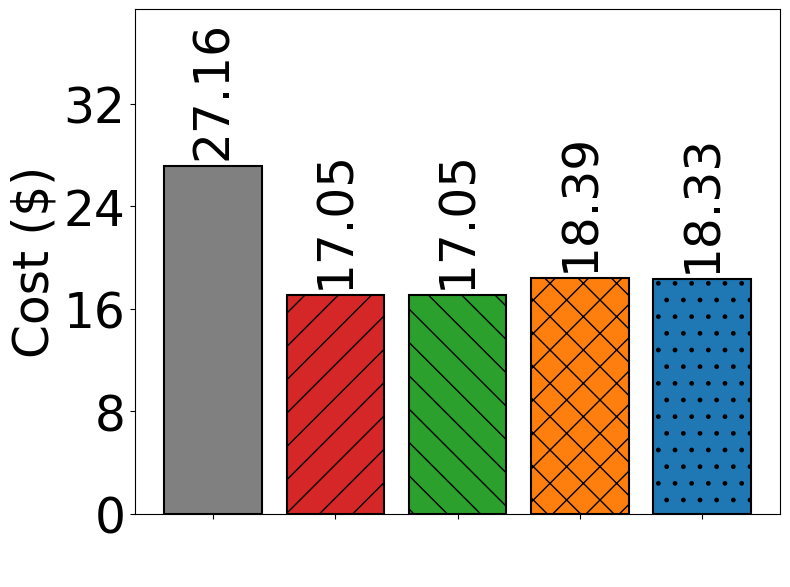

Saved: figures/cost_comparison_scenario_A_llama3_70b.pdf


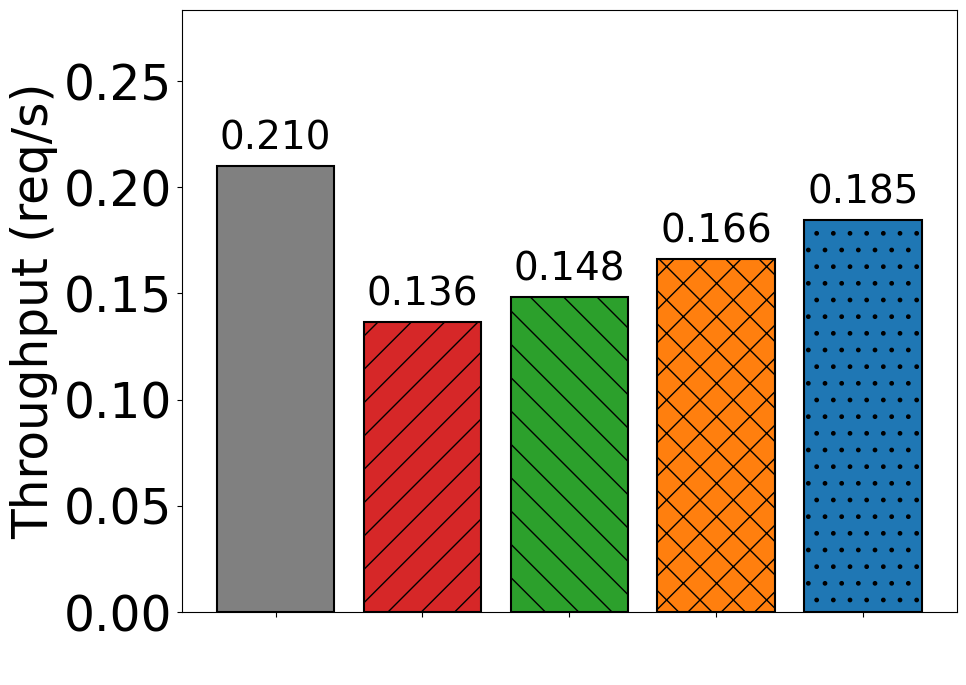

Saved: figures/throughput_scenario_A_llama3_70b.pdf
Offline Cost/Throughput (normalized, lower=cheaper):
  only_ondemand                        1.000  (baseline)
  no_handle                            0.967  (+3.3%)
  request_migration                    0.889  (+11.1%)
  concurrent_initialization            0.855  (+14.5%)
  shuntserve                           0.769  (+23.1%)


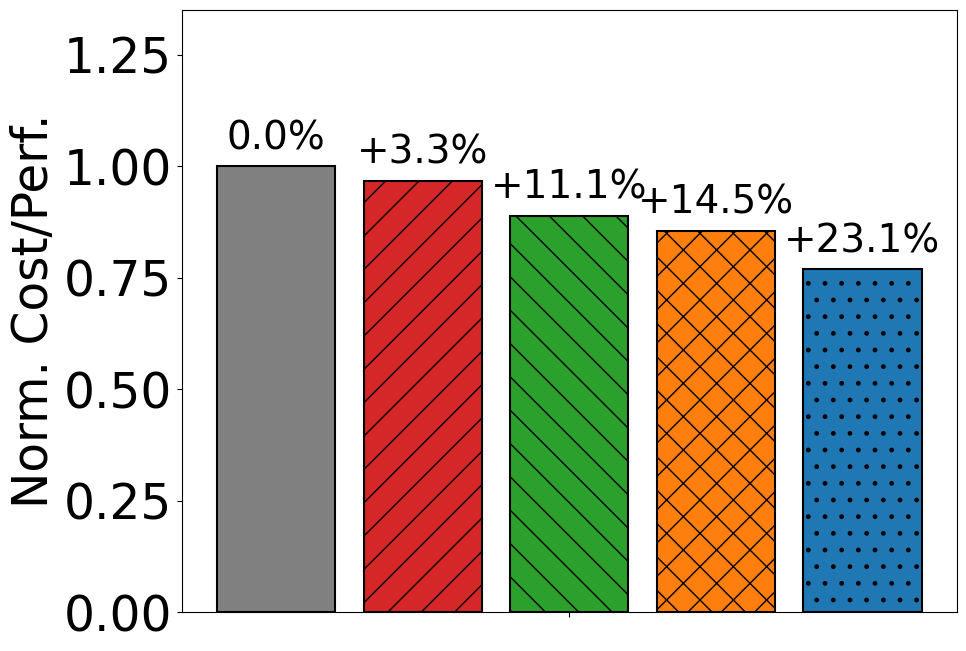

Saved: figures/cost_efficiency_scenario_A_llama3_70b.pdf


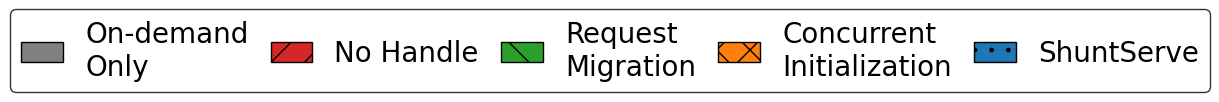

Saved: figures/cost_legend_scenario_A_llama3_70b.pdf


In [9]:
run_analysis("llama3-70b")

## Azure Conversation vs. Mooncake Tool-Agent — comparison

Same scenario (identical spot-event timeline, node inventory, offline window); only the **dataset** — and hence the optimizer's placement — differs. Azure Conversation is short-context; Mooncake Tool-Agent is long-context. Both datasets are run through the **same** metric + cost pipeline so the numbers are directly comparable.

- **Throughput** — Average RPS (paper fig13-14 metric: mean of a 5-min trailing-window completion rate over the offline window).
- **%OD** — throughput retained relative to On-demand Only (=100%); higher = more interruption-tolerant.
- **Cost / Norm. Cost-Perf** — `avg` spot-price mode; Norm. Cost/Perf is Cost ÷ Throughput, normalized to On-demand Only = 1.00 (lower = cheaper per unit work).

In [10]:
# ── Azure Conversation vs Mooncake Tool-Agent — comparison table ─────────────────
import io as _io, contextlib as _ctx, os as _os

# Read in tolerance order (best → worst), matching the earlier %OD comparison.
TABLE_ORDER = ["only_ondemand", "shuntserve", "concurrent_initialization",
               "request_migration", "no_handle"]

def _dataset_avg_io(csv_rel):
    df = pd.read_csv(csv_rel)
    return df["ContextTokens"].mean(), df["GeneratedTokens"].mean()

def _compute_dataset(base_dir, model_key="llama3-70b"):
    """Full metric + cost pipeline against a dataset tree.
    All loaders are cwd-relative, so we chdir in/out under try/finally."""
    cfg = MODEL_CONFIGS[model_key]
    bdm, az_sel = cfg["benchmark_duration_min"], cfg["az_selection"]
    cwd0 = _os.getcwd()
    try:
        _os.chdir(base_dir)
        with _ctx.redirect_stdout(_io.StringIO()):          # silence the per-load prints
            data    = load_data(model_key, SCENARIO)
            metrics = parse_metrics(model_key, SCENARIO, bdm, APPROACHES)
            periods = compute_active_periods(data["events_raw"], data["initial_state"],
                                             data["instance_types"], bdm)
            cost_results, modes = compute_costs(data, periods, metrics, az_sel, bdm, APPROACHES)
    finally:
        _os.chdir(cwd0)

    costs, tput = cost_results[modes[0]], metrics["throughputs"]
    base_t = tput.get("only_ondemand")
    pct_od = {a: 100.0 * tput[a] / base_t for a in tput} if base_t else {}
    cpp = {a: costs[a] / tput[a] for a in TABLE_ORDER if a in costs and tput.get(a, 0) > 0}
    base_cpp = cpp.get("only_ondemand")
    eff = {a: cpp[a] / base_cpp for a in cpp} if base_cpp else {}
    return {"tput": tput, "pct_od": pct_od, "cost": costs, "eff": eff, "bdm": bdm}

_azure = _compute_dataset("../AzureConversation")
_moon  = _compute_dataset(".")

_a_in, _a_out = _dataset_avg_io("../../Datasets/AzureLLMInferenceConvTrace_pruned_2048.csv")
_m_in, _m_out = _dataset_avg_io("../../Datasets/MooncakeToolAgentTrace_pruned_16384.csv")

_METRICS = [("Throughput (req/s)", "tput", "{:.3f}"),
            ("%OD",                "pct_od", "{:.1f}"),
            ("Cost ($)",           "cost", "{:.2f}"),
            ("Norm. Cost/Perf",    "eff",  "{:.3f}")]
_DS = [("Azure", _azure), ("Mooncake", _moon)]

_cols = {}
for _ml, _mk, _fmt in _METRICS:
    for _dn, _d in _DS:
        _cols[(_ml, _dn)] = [_fmt.format(_d[_mk][a]) if a in _d[_mk] else "—"
                             for a in TABLE_ORDER]

_cmp = pd.DataFrame(_cols, index=[DISPLAY_NAMES[a].replace("\n", " ") for a in TABLE_ORDER])
_cmp.columns = pd.MultiIndex.from_tuples(_cmp.columns)
_cmp.index.name = "Method"

print(f"Scenario {SCENARIO} — offline — {_moon['bdm']}-min window")
print(f"  Azure Conversation  (short-context): avg {_a_in:.0f} in / {_a_out:.0f} out")
print(f"  Mooncake Tool-Agent (long-context) : avg {_m_in:.0f} in / {_m_out:.0f} out")
display(_cmp)


Scenario A — offline — 50-min window
  Azure Conversation  (short-context): avg 763 in / 232 out
  Mooncake Tool-Agent (long-context) : avg 5745 in / 154 out


Throughput (req/s)             %OD           \
                                       Azure Mooncake  Azure Mooncake   
Method                                                                  
On-demand Only                         1.228    0.210  100.0    100.0   
ShuntServe                             1.115    0.185   90.8     87.8   
Concurrent Initialization              1.026    0.166   83.5     79.2   
Request Migration                      0.922    0.148   75.0     70.6   
No Handle                              0.848    0.136   69.1     64.9   

                          Cost ($)          Norm. Cost/Perf           
                             Azure Mooncake           Azure Mooncake  
Method                                                                
On-demand Only               27.16    27.16           1.000    1.000  
ShuntServe                   18.44    18.33           0.748    0.769  
Concurrent Initialization    18.43    18.39           0.812    0.855  
Request Migration            17.05    17.05           0.837    0.889  
No Handle                    17.05    17.05           0.909    0.967

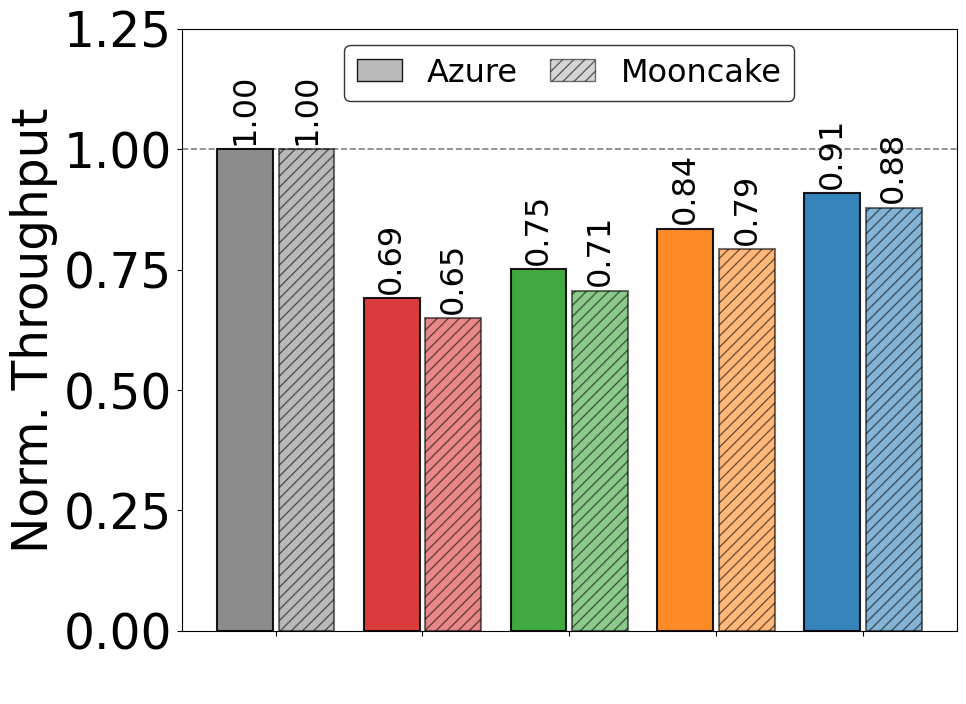

Saved: figures/norm_throughput_compare_scenario_A_llama3_70b.pdf


In [11]:
# ── Normalized-throughput comparison figure (Azure solid vs Mooncake hatched) ───
plot_norm_throughput_comparison(_azure, _moon, "llama3-70b")
